In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import welch



file = Path("Time_Trace_3324.bin")  

with open(file, "rb") as f:
    rows_i, cols_i = np.fromfile(f, dtype=">u4", count=2)
    data_i = np.fromfile(f, dtype=">f8")

arr_i = data_i.reshape((rows_i, cols_i))[:-1, :]

time = arr_i[:, 0]
pixels_V = arr_i[:, 1:]   # voltage traces, one column per pixel

print("File:", file)
print("Rows:", rows_i)
print("Columns:", cols_i)
print("Used samples:", len(time))
print("Number of pixels:", pixels_V.shape[1])

File: Time_Trace_3324.bin
Rows: 46869
Columns: 50
Used samples: 46868
Number of pixels: 49


In [22]:
#sampling f and bandwidth

dt = np.mean(np.diff(time))
fs = 1 / dt

N = len(time)
total_time = N * dt

df = fs / N
bandwidth = fs / 2

print(f"dt = {dt:.6e} s")
print(f"fs = {fs:.6f} Hz")
print(f"N = {N}")
print(f"Total time = {total_time:.6f} s")
print(f"Frequency spacing df = fs/N = {df:.6f} Hz")
print(f"Measurement bandwidth = Nyquist frequency = fs/2 = {bandwidth:.6f} Hz")

dt = 2.160000e-05 s
fs = 46296.296296 Hz
N = 46868
Total time = 1.012349 s
Frequency spacing df = fs/N = 0.987802 Hz
Measurement bandwidth = Nyquist frequency = fs/2 = 23148.148148 Hz


In [23]:
pixels_V_zero_mean = pixels_V - np.mean(pixels_V, axis=0) #subtract mean, fft it

segment_length_s = 1

nperseg = int(segment_length_s * fs)
nperseg = min(nperseg, N)
noverlap = nperseg // 2

freqs, PSD_V = welch(
    pixels_V_zero_mean,
    fs=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
    detrend=False,
    return_onesided=True,
    scaling="density",
    axis=0
)

df_welch = freqs[1] - freqs[0]


In [24]:
ASD_V = np.sqrt(PSD_V)#  V/sqrt(Hz)

slope_dV_df = 5e-8
gamma_e = 28.02495164e9

slope_dV_dB = slope_dV_df * gamma_e #V/Hz

ASD_B_T = ASD_V / slope_dV_dB
ASD_B_nT = ASD_B_T * 1e9


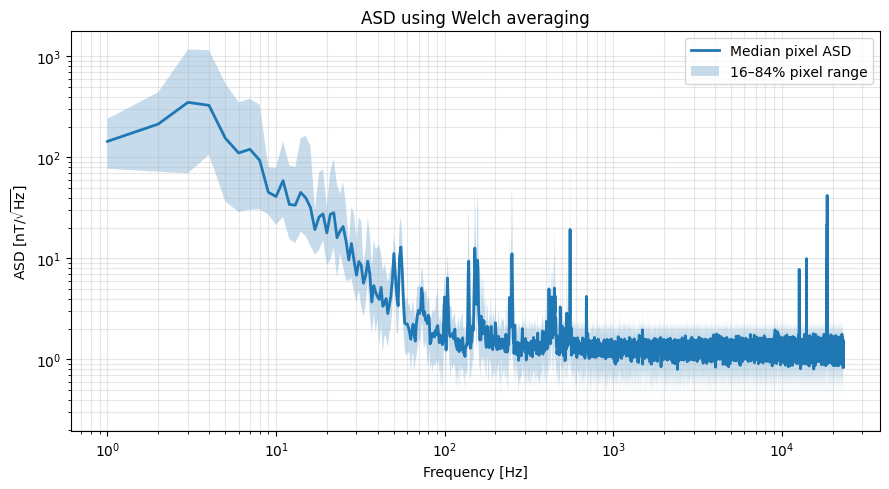

In [25]:
ASD_median = np.median(ASD_B_nT, axis=1)
ASD_16 = np.percentile(ASD_B_nT, 16, axis=1)
ASD_84 = np.percentile(ASD_B_nT, 84, axis=1)

plt.figure(figsize=(9, 5))

plt.loglog(freqs[1:], ASD_median[1:], linewidth=2, label="Median pixel ASD")

plt.fill_between(
    freqs[1:],
    ASD_16[1:],
    ASD_84[1:],
    alpha=0.25,
    label="16–84% pixel range"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [nT/$\sqrt{\mathrm{Hz}}$]")
plt.title("ASD using Welch averaging")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# ------------------------------------------------------------
# 8. Try several sensitivity bands
# ------------------------------------------------------------

candidate_bands = [
    (100, 500),
    (300, 1000),
    (500, 3000),
    (1000, 5000),
    (300, 3000),
    (1000, 7000),
]

print("Candidate sensitivity bands")
print("---------------------------")

for fmin, fmax in candidate_bands:
    band = (freqs >= fmin) & (freqs <= fmax)

    eta_pixels = np.median(ASD_B_nT[band, :], axis=0)

    eta_med = np.median(eta_pixels)
    eta_16 = np.percentile(eta_pixels, 16)
    eta_84 = np.percentile(eta_pixels, 84)

    print(f"{fmin:5.0f}–{fmax:<5.0f} Hz : "
          f"{eta_med:8.4g} nT/sqrt(Hz) "
          f"({eta_med*1000:8.4g} pT/sqrt(Hz)), "
          f"16–84%: {eta_16:.4g}–{eta_84:.4g}")

Candidate sensitivity bands
---------------------------
  100–500   Hz :     1.49 nT/sqrt(Hz) (    1490 pT/sqrt(Hz)), 16–84%: 1.277–2.111
  300–1000  Hz :     1.35 nT/sqrt(Hz) (    1350 pT/sqrt(Hz)), 16–84%: 1.208–1.619
  500–3000  Hz :    1.264 nT/sqrt(Hz) (    1264 pT/sqrt(Hz)), 16–84%: 1.183–1.402
 1000–5000  Hz :    1.257 nT/sqrt(Hz) (    1257 pT/sqrt(Hz)), 16–84%: 1.182–1.379
  300–3000  Hz :     1.29 nT/sqrt(Hz) (    1290 pT/sqrt(Hz)), 16–84%: 1.186–1.435
 1000–7000  Hz :    1.257 nT/sqrt(Hz) (    1257 pT/sqrt(Hz)), 16–84%: 1.178–1.375


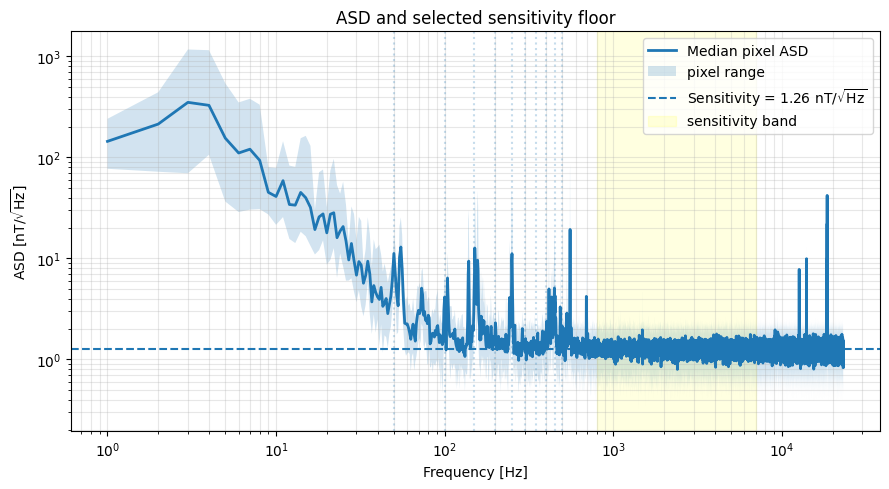

In [27]:
# ------------------------------------------------------------
# 10. Plot ASD with selected sensitivity band
# ------------------------------------------------------------


band = (freqs >= 800) & (freqs <= 7000)

eta_pixels = np.median(ASD_B_nT[band, :], axis=0)

eta_median_nT = np.median(eta_pixels)

plt.figure(figsize=(9, 5))

plt.loglog(freqs[1:], ASD_median[1:], linewidth=2, label="Median pixel ASD")

plt.fill_between(
    freqs[1:],
    ASD_16[1:],
    ASD_84[1:],
    alpha=0.20,
    label="pixel range"
)

plt.axhline(
    eta_median_nT,
    linestyle="--",
    label=rf"Sensitivity = {eta_median_nT:.3g} nT/$\sqrt{{\mathrm{{Hz}}}}$"
)

plt.axvspan(800, 7000, alpha=0.12, color="yellow", label="sensitivity band")

for f0 in [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    if f0 < freqs[-1]:
        plt.axvline(f0, linestyle=":", alpha=0.25)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [nT/$\sqrt{\mathrm{Hz}}$]")
plt.title("ASD and selected sensitivity floor")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# ------------------------------------------------------------
# Report-ready sensitivity statistics
# ------------------------------------------------------------

selected_band = (800, 7000)   # Hz
fmin, fmax = selected_band
band = (freqs >= fmin) & (freqs <= fmax)

eta_pixels_nT = np.median(ASD_B_nT[band, :], axis=0)

eta_median = np.median(eta_pixels_nT)
eta_mean = np.mean(eta_pixels_nT)
eta_std = np.std(eta_pixels_nT, ddof=1)
eta_16 = np.percentile(eta_pixels_nT, 16)
eta_25 = np.percentile(eta_pixels_nT, 25)
eta_75 = np.percentile(eta_pixels_nT, 75)
eta_84 = np.percentile(eta_pixels_nT, 84)
eta_min = np.min(eta_pixels_nT)
eta_max = np.max(eta_pixels_nT)

print("Report-ready sensitivity statistics")
print("-----------------------------------")
print(f"File                         : {file}")
print(f"Number of pixels             : {pixels_V.shape[1]}")
print(f"Samples per pixel            : {N}")
print(f"Total trace duration          : {total_time:.6f} s")
print(f"Sampling frequency            : {fs:.3f} Hz")
print(f"Nyquist bandwidth             : {bandwidth:.3f} Hz")
print(f"Frequency spacing             : {df:.6f} Hz")
print(f"Welch nperseg                 : {nperseg}")
print(f"Welch frequency spacing        : {df_welch:.6f} Hz")
print()
print(f"ODMR slope dV/df              : {slope_dV_df:.3e} V/Hz")
print(f"Gyromagnetic ratio gamma_e     : {gamma_e:.6e} Hz/T")
print(f"Voltage-to-field slope dV/dB   : {slope_dV_dB:.6e} V/T")
print()
print(f"Selected sensitivity band      : {fmin:.0f}–{fmax:.0f} Hz")
print(f"Median sensitivity             : {eta_median:.4f} nT/sqrt(Hz)")
print(f"Mean sensitivity               : {eta_mean:.4f} nT/sqrt(Hz)")
print(f"Standard deviation across pixels: {eta_std:.4f} nT/sqrt(Hz)")
print(f"16–84 percentile range          : {eta_16:.4f}–{eta_84:.4f} nT/sqrt(Hz)")
print(f"25–75 percentile range          : {eta_25:.4f}–{eta_75:.4f} nT/sqrt(Hz)")
print(f"Minimum–maximum across pixels   : {eta_min:.4f}–{eta_max:.4f} nT/sqrt(Hz)")
print()
print("In pT/sqrt(Hz):")
print(f"Median sensitivity             : {eta_median*1000:.1f} pT/sqrt(Hz)")
print(f"16–84 percentile range          : {eta_16*1000:.1f}–{eta_84*1000:.1f} pT/sqrt(Hz)")

Report-ready sensitivity statistics
-----------------------------------
File                         : Time_Trace_3324.bin
Number of pixels             : 49
Samples per pixel            : 46868
Total trace duration          : 1.012349 s
Sampling frequency            : 46296.296 Hz
Nyquist bandwidth             : 23148.148 Hz
Frequency spacing             : 0.987802 Hz
Welch nperseg                 : 46296
Welch frequency spacing        : 1.000006 Hz

ODMR slope dV/df              : 5.000e-08 V/Hz
Gyromagnetic ratio gamma_e     : 2.802495e+10 Hz/T
Voltage-to-field slope dV/dB   : 1.401248e+03 V/T

Selected sensitivity band      : 800–7000 Hz
Median sensitivity             : 1.2601 nT/sqrt(Hz)
Mean sensitivity               : 1.2716 nT/sqrt(Hz)
Standard deviation across pixels: 0.1027 nT/sqrt(Hz)
16–84 percentile range          : 1.1779–1.3756 nT/sqrt(Hz)
25–75 percentile range          : 1.1965–1.3445 nT/sqrt(Hz)
Minimum–maximum across pixels   : 1.0840–1.5746 nT/sqrt(Hz)

In pT/sqrt(Hz